# Lecture 13 — Molecular Chemistry: the Coupled Equilibrium and Continuous Opacity

*Stellar Spectroscopy from Scratch — rebuilding the physics of ATLAS and SYNTHE from first principles*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*Every result in this book is checked against reference values computed with [**pykurucz**](https://arxiv.org/abs/2603.11693) — a pure-Python implementation of Kurucz's ATLAS12 and SYNTHE — shipped beside the lectures as small data files, so the notebooks need only NumPy to run.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Explain why molecular chemistry in a stellar atmosphere is a **coupled** problem: every molecule competes for the same pool of atoms, and the negative ions tie the chemistry to the **electron density**, so a single formation constant $K_f$ per molecule is not enough — the balances must be solved **together**.
- Assemble the coupled conservation system the production code solves: one **total-particle** equation, one **number-conservation** equation per element, and one **charge-balance** equation, with every molecule's contribution written through its formation constant.
- Solve that nonlinear system the way pykurucz does — a **Newton–Raphson** iteration whose linear step is a **complete-pivoting Gauss–Jordan** elimination (the Fortran SOLVIT) — and recover ~14000 molecular number densities, the neutral-atom densities, and the electron density, matching the production code to $\sim10^{-13}$.
- Compute the **molecular continuous opacity** of a cool dwarf from scratch: the **CH** (CHOP) and **OH** (OHOP) band-like cross-sections interpolated from tables, and **H$_2$ collision-induced absorption** (H$_2$-CIA, the Borysow tables) — two H$_2$ molecules forming a transient supermolecule with an induced dipole.
- Show that **H$_2$-CIA is essentially the entire molecular continuum across 1–2.2 $\mu$m**, exactly where an M dwarf's flux peaks, and reproduce the production continuum **bit-for-bit**.

## Introduction

Lecture 12 synthesised a cool M dwarf's TiO band, and to do it we made two purchases on credit. We **read** the molecular number densities out of the converged model atmosphere — pykurucz's already-solved answer — and used them to drive the band opacity. And we drew the spectrum on a continuum that, for a cool star, is not the simple H$^-$ continuum of the warmer Sun. Both were taken as given. This lecture pays the debt: we **earn** the molecular populations by solving the chemistry ourselves, and we **earn** the cool-star continuum by computing the molecular continuous opacity from scratch. After this lecture the book has no remaining cool-star cheat — the molecular physics is built, not borrowed.

The first half is the chemistry. In Lecture 12 we wrote the formation balance of a single molecule, Ti + O $\rightleftharpoons$ TiO, as a Saha-like law with one equilibrium constant $K_f(T)$. That is correct but incomplete, because the molecules are not independent. Oxygen does not belong to TiO alone — it is also pulled into CO, OH, H$_2$O, SiO, and a dozen other species, all drawing on the **same** finite supply of oxygen nuclei. Carbon competes for the same oxygen through CO. Hydrogen locks itself into H$_2$. And the negative molecular ions (such as H$^-$, treated here as a "molecule" of H plus an electron) tie the whole network to the **electron density**, which is itself set by the ionisation balance. So the populations are the solution of a **coupled** nonlinear system: conserve every element's total nuclei, conserve charge, and let every molecule's law of mass action hold simultaneously. A per-molecule $K_f$ is the input to that system, not the answer.

The second half is the continuum. A warm star's continuum is H$^-$ bound-free and free-free (Lecture 3); a cool dwarf adds molecular sources. Two matter here. **CH and OH** contribute band-like continuous absorption in the blue and ultraviolet — part of why cool dwarfs are so dark there. And in the near-infrared, where an M dwarf radiates most of its light, the dominant continuum source is **collision-induced absorption by molecular hydrogen**: when two H$_2$ molecules (or an H$_2$ and a helium atom) collide, the fleeting complex has an induced dipole that can absorb a photon, even though an isolated H$_2$ molecule, being symmetric, cannot. This H$_2$-CIA is smooth, broad, and — as we will show — essentially **100%** of the molecular continuum from 1 to 2.2 $\mu$m. We compute all three (CHOP, OHOP, H$_2$-CIA) from the atmosphere state plus tabulated coefficients and match the production opacity bit-for-bit.

Both halves are benchmarked the same way as every lecture in this book: COMPUTE the quantity from inputs, then load pykurucz's output **only** to measure the error. The coupled solver matches to a float64 non-associativity floor of $\sim10^{-13}$ (the molecular formation physics itself is bit-exact); the molecular continuum matches to machine zero.

A schematic for this lecture would help fix the two ideas. It is described here and generated separately; the notebook does not draw it.

![Left: the coupled equilibrium network — a central pool of element nuclei (O, C, H, Ti, ...) and a shared electron reservoir, with arrows pulling atoms into competing molecules (CO, OH, H2O, TiO, H2, H-), every molecule a node tied back to the pools it draws from, illustrating that no single molecule can be solved alone. Right: two H2 molecules drifting into a momentary collision complex with a transient induced dipole (a curved double-headed arrow marking the dipole), absorbing an infrared photon — collision-induced absorption — beside a smooth opacity-vs-wavelength curve peaking in the near-infrared where an M dwarf's flux peaks.](resources/figures/s13_molchem.png)

## Part 1 — The coupled molecular equilibrium

### Why the molecules must be solved together

Recall the law of mass action from Lecture 12. For a molecule built from atoms with number densities $n_1, n_2, \dots$, the equilibrium molecular density is

$$
n_{\rm mol} = K_f(T)\,\prod_i n_i ,
$$

where $K_f(T)$ is the formation constant — the Saha-for-molecules quantity, $D_0/kT$ plus a temperature polynomial — that Lecture 12 read from `molecules.dat`. If there were one molecule and unlimited atoms, that single equation would be the whole story.

There is not. Consider oxygen at 3500 K. The oxygen nuclei are distributed among neutral O, ionised O$^+$, and every oxygen-bearing molecule — CO, OH, H$_2$O, SiO, TiO, VO, and more. **Carbon's** chemistry is welded to oxygen's through CO, which is so tightly bound ($D_0 \approx 11$ eV) that it consumes nearly all of whichever of C or O is less abundant. **Hydrogen** mostly disappears into H$_2$. And the electron density $n_e$, set by metal ionisation, feeds back through negative ions. Change the assumed O density and every oxygen molecule's population changes, which changes how much O is left as a free atom, which changes the molecules again. The balances are **circular**, and the only consistent solution is the one that satisfies them all at once subject to two hard constraints:

- **number conservation** — the nuclei of each element, summed over its free atom and every molecule that contains it, must equal the element's total abundance;
- **charge conservation** — the free electrons must balance the net positive charge.

This is a coupled nonlinear system. The unknowns are the neutral-atom density of each element and the electron density; the equations are total-particle conservation, one number-conservation equation per element, and charge balance. The production routine that solves it is called **NMOLEC**, and the rest of Part 1 builds it from scratch.

### Loading the cool-dwarf atmosphere and the molecular data

We work on the same cool M-dwarf model as Lecture 12 (Teff = 3500 K, $\log g = 5.0$), reduced to the few per-depth quantities the chemistry needs: temperature, gas pressure, a starting electron density, and the element abundances. Everything else the solver derives itself. The abundances `xabund` are number fractions relative to the total of heavy nuclei, indexed by atomic number.

We also load the production ion equilibrium constants `equilj_ion`. These are the formation constants of the **atomic ions** (H$^+$, C$^+$, Mg$^+$, ...), which come from the atomic Saha/partition-function routine (Lectures 2–3) — atomic-ionisation physics, an *input* to the molecular solver, not part of it. The molecule-formation constants (TiO, H$_2$, CO, OH, ...) — the physics this lecture is about — we recompute ourselves below and check against these values.

The ground-truth file `nmolec_groundtruth.npz` is loaded much later, in a clearly separated block, **only** to measure precision. The solver never reads it.

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt

# shared plot styling for the whole notebook
plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5})

REF = pathlib.Path("..") / "reference"

# the cool M-dwarf atmosphere state the chemistry needs, per depth (80 layers)
inp = np.load(REF / "nmolec_inputs.npz")
T            = inp["temperature"].astype(float)        # K
gas_pressure = inp["gas_pressure"].astype(float)       # dyn/cm^2
xne0         = inp["electron_density"].astype(float)   # cm^-3, only a seed for the iteration
xabund       = inp["xabund"].astype(float)             # number fraction by atomic number

# atomic-ion formation constants from the Saha routine (an INPUT: atomic physics, Lectures 2-3)
equilj_ion = inp["equilj_ion"].astype(float)           # (n_layers, nummol)
poly_mask  = inp["poly_mask"].astype(bool)             # True = a molecule we recompute from scratch

n_layers = T.size
print(f"M dwarf: {n_layers} depths, T = {T.min():.0f}..{T.max():.0f} K")
print(f"polynomial molecules (recomputed here): {int(poly_mask.sum())}")
print(f"ion molecules (atomic-physics input)  : {int((~poly_mask).sum())}")

M dwarf: 80 depths, T = 2464..5250 K
polynomial molecules (recomputed here): 96
ion molecules (atomic-physics input)  : 94


### Decoding `molecules.dat`: which atoms, which equations

The dissociation table `molecules.dat` is a fixed-width text file. Each molecule's line begins with a **code** that packs the constituent atoms into base-100 digits, followed by the dissociation energy $D_0$ and the six-term temperature polynomial of the formation constant. The decoder below is the from-scratch port of the Fortran READMOL routine. For each line it

1. reads the code and the seven coefficients from their fixed columns;
2. peels the code apart base-100 to recover the list of constituent **element ids** (a zero digit means an electron, id 100), and reads the trailing fractional digits as the net **charge** `ion` (each unit of positive charge adds an *inverse electron*, id 101 — a "divide by $n_e$" in the molecule's mass-action product);
3. records, per molecule, the slice of components and the polynomial coefficients.

After all molecules are read it assigns an **equation number** to every element that appears anywhere, plus one for the electron, and rewrites each component as a 0-based equation index. The inverse electron maps to a sentinel index (one past the last equation) that the solver reads as "divide by $n_e$". The returned arrays — `code_mol`, `equil`, `locj` (component slices), `kcomps` (component equation indices), `idequa` (which element each equation conserves), and `nequa` — are exactly the data structures the Newton solver consumes.

In [2]:
MAXMOL = 200
MAXEQ = 30
MAXLOC = 3 * MAXMOL

def readmol(path):
    """Parse molecules.dat into the molecular-equilibrium data structures (port of READMOL).

    Returns (nummol, code_mol, equil(7,MAXMOL), locj, kcomps, idequa, nequa).
    kcomps holds 0-based EQUATION indices; an inverse electron maps to the sentinel
    index nequa (signals 'divide by n_e' in a molecule's mass-action product).
    """
    code_mol = np.zeros(MAXMOL)
    equil = np.zeros((7, MAXMOL))          # D0 then E1..E6 per molecule
    locj = np.zeros(MAXMOL + 1, dtype=np.int32)   # locj[j]..locj[j+1] = molecule j's components
    kcomps = np.zeros(MAXLOC, dtype=np.int32)     # element id per component (rewritten to eq index)
    idequa = np.zeros(MAXEQ, dtype=np.int32)      # element id conserved by each equation
    ifequa = np.zeros(102, dtype=np.int32)        # element id -> equation number

    # base-100 place values for decoding the atom code
    xcode = np.array([1e14, 1e12, 1e10, 1e8, 1e6, 1e4, 1e2, 1e0])

    kloc = 0
    locj[0] = 0
    nummol = 0
    # fixed-width columns: F18.2 code, then 6E11.4 coefficients
    cols = [(18, 25), (25, 36), (36, 47), (47, 58), (58, 69), (69, 80), (80, 91)]

    for raw in path.read_text().splitlines():
        line = raw.rstrip("\n\r")
        stripped = line.strip()
        # skip blanks and comment lines
        if not stripped or stripped[:1] in ("C", "c", "#"):
            continue
        c_str = line[0:min(18, len(line))].strip()
        if not c_str:
            continue
        try:
            c = float(c_str)                       # the packed atom code
        except ValueError:
            continue
        # read the seven coefficients from their fixed columns (blanks -> 0)
        ee = [0.0] * 7
        for i, (a, b) in enumerate(cols):
            if len(line) >= b:
                s = line[a:b].strip()
                if s:
                    ee[i] = float(s)
        if abs(c) < 1e-12:
            continue

        # find the highest occupied base-100 place
        ii = 0
        for i in range(8):
            if c >= xcode[i]:
                ii = i
                break
        # peel out each element id base-100; a zero digit means an electron (id 100)
        x = c
        for i in range(ii, 8):
            id_elem = int(x / xcode[i])
            x = x - float(id_elem) * xcode[i]
            if id_elem == 0:
                id_elem = 100
            ifequa[id_elem] = 1
            kcomps[kloc] = id_elem
            kloc += 1
        # the trailing fractional digits are the net charge: each + adds an inverse electron (101)
        ion = int(x * 100.0 + 0.5)
        if ion >= 1:
            ifequa[100] = 1
            ifequa[101] = 1
            for _ in range(ion):
                kcomps[kloc] = 101
                kloc += 1

        locj[nummol + 1] = kloc
        code_mol[nummol] = c
        for i in range(7):
            equil[i, nummol] = ee[i]
        nummol += 1

    nloc = kloc

    # assign equation numbers: equation 0 is the total-particle slot (never an element)
    iequa = 1
    for i in range(1, 101):
        if ifequa[i] == 1:
            iequa += 1
            ifequa[i] = iequa
            idequa[iequa - 1] = i
    nequa = iequa
    ifequa[101] = nequa + 1                 # inverse electron -> sentinel equation index

    # rewrite each component from an element id to a 0-based equation index
    for k in range(nloc):
        kcomps[k] = ifequa[kcomps[k]] - 1

    return nummol, code_mol, equil, locj, kcomps, idequa, nequa

nummol, code_mol, equil, locj, kcomps, idequa, nequa = readmol(REF / "molecules.dat")
print(f"parsed {nummol} molecules into {nequa} equations")

parsed 190 molecules into 23 equations


The `nequa` equations are the conservation laws of the coupled system: equation 0 is the total-particle balance, the middle equations conserve the nuclei of each element that appears in any molecule, and the last conserves charge. Let us name them so the structure is concrete.

In [3]:
# map each equation's conserved-element id to a readable label
SYM = {1:"H", 2:"He", 3:"Li", 4:"Be", 5:"B", 6:"C", 7:"N", 8:"O", 9:"F",
       11:"Na", 12:"Mg", 13:"Al", 14:"Si", 16:"S", 17:"Cl", 19:"K", 20:"Ca",
       22:"Ti", 23:"V", 24:"Cr", 26:"Fe", 100:"e-"}

labels = []
for k in range(nequa):
    eid = int(idequa[k])
    if k == 0:
        labels.append("total")               # equation 0 = total-particle conservation
    else:
        labels.append(SYM.get(eid, f"Z={eid}"))

print(f"{nequa} equations:")
print("  [0] total-particle conservation")
print("  elements :", " ".join(labels[1:-1]))
print("  [last] charge balance (electron eq id =", int(idequa[nequa - 1]), ")")

23 equations:
  [0] total-particle conservation
  elements : H He Li Be B C N O F Na Mg Al Si S Cl K Ca Ti V Cr Fe
  [last] charge balance (electron eq id = 100 )


### The molecular formation constants $K_f(T)$ from scratch

The coupled system needs, at every depth, the formation constant of every molecule. For the **polynomial** molecules (TiO, H$_2$, CO, OH, CH, ...) — the molecule-formation physics this lecture owns — we evaluate the NMOLEC formula from Lecture 12, written in the same Horner form and with the same Fortran constant $kT = 8.6171\times10^{-5}\,T$ eV:

$$
\log K_f(T) = \frac{D_0}{kT} - E_1 + \big(E_2 + (-E_3 + (E_4 + (-E_5 + E_6 T)T)T)T\big)\,T \;-\; \tfrac32\,(n_{\rm comp} - 2\,{\rm ion} - 1)\,\log T .
$$

The first term is the binding Boltzmann factor; the polynomial packages the partition-function ratio; the last is the phase-space $(kT)^{3/2}$ scaling per atom removed. Two special cases match the production code exactly: molecules above 10000 K are skipped (no molecules survive), and the H$^-$/H$_2$-dissociation entry (code 101) uses its own hard-coded polynomial. The atomic-ion molecules (`equil[0]==0`) are left at zero here and filled from the shipped Saha input.

In [4]:
KBOLTZ_EV = 8.617333262e-5     # eV/K, the value pykurucz's mol equilibrium uses for tkev

def compute_equilj_polynomial(j, T, tkev, tlog):
    """K_f(T) for every POLYNOMIAL molecule at depth j (the lecture's physics).

    Ion (PFSAHA) molecules are left at 0.0 and supplied from the shipped atomic input.
    """
    eqj = np.zeros(nummol)
    for jmol in range(nummol):
        # equil[0]==0 marks an atomic-ion molecule: supplied as input, not computed here
        if equil[0, jmol] == 0.0:
            continue
        ncomp = locj[jmol + 1] - locj[jmol]
        code_int = int(code_mol[jmol])
        ion = int((code_mol[jmol] - code_int) * 100.0 + 0.5)   # net charge from trailing digits
        # no molecules survive above 10000 K
        if T[j] > 10000.0:
            continue
        if abs(code_mol[jmol] - 101.0) < 1e-9:
            # the H-/H2-dissociation entry uses its own hard-coded polynomial
            ea = (4.478 / tkev[j] - 46.4584
                  + (1.63660e-3 + (-4.93992e-7 + (1.11822e-10 + (-1.49567e-14
                     + (1.06206e-18 - 3.08720e-23 * T[j]) * T[j]) * T[j]) * T[j])
                     * T[j]) * T[j] - 1.5 * tlog[j])
            eqj[jmol] = np.exp(ea)
            continue
        # binding term + Horner polynomial (partition-function fit)
        poly = (equil[0, jmol] / tkev[j] - equil[1, jmol]
                + (equil[2, jmol] + (-equil[3, jmol] + (equil[4, jmol]
                   + (-equil[5, jmol] + equil[6, jmol] * T[j]) * T[j]) * T[j])
                   * T[j]) * T[j])
        # phase-space (kT)^{3/2} term, one factor per atom removed
        tlog_term = -1.5 * float(ncomp - ion - ion - 1) * tlog[j]
        eqj[jmol] = np.exp(poly + tlog_term)
    return eqj

Before using these constants, we **prove** our from-scratch evaluation reproduces the production EQUILJ bit-for-bit. The shipped `equilj_ion` array holds the production formation constants for *all* molecules (ion and polynomial); for the polynomial ones it must match our computation exactly, since both evaluate the same physics. A nonzero residual here would mean our molecular physics is wrong — so this is the gate the rest of Part 1 stands on.

In [5]:
tkev_all = KBOLTZ_EV * T
tlog_all = np.log(T)

# compare our recomputed polynomial K_f(T) against the shipped production values
worst_poly = 0.0
for j in range(n_layers):
    # our from-scratch formation constants at this depth
    eqj = compute_equilj_polynomial(j, T, tkev_all, tlog_all)
    for jmol in range(nummol):
        # only the polynomial molecules are computed here; ignore zeros
        if poly_mask[jmol] and equilj_ion[j, jmol] > 0:
            r = abs(eqj[jmol] - equilj_ion[j, jmol]) / abs(equilj_ion[j, jmol])
            worst_poly = max(worst_poly, r)

print(f"from-scratch K_f(T) vs production EQUILJ : max rel = {worst_poly:.3e}",
      "(BIT-EXACT)" if worst_poly == 0.0 else "")
assert worst_poly == 0.0, "molecular formation physics must be bit-exact"

from-scratch K_f(T) vs production EQUILJ : max rel = 0.000e+00 (BIT-EXACT)


### Assembling the system, part A: the conservation equations

Newton's method needs, at each iteration, the residual vector `eq` (how far each conservation law is from being satisfied) and the Jacobian matrix `deq` (how each residual changes when each unknown changes). We build them in two stages. **Stage A**, this cell, lays down the conservation skeleton before any molecules are added:

- the **total-particle** residual (equation 0) starts at $-n_{\rm tot}$ and accumulates every element's neutral density, so it reads "sum of heavy particles minus the total"; its Jacobian row is all ones;
- each **element** residual starts as $n_k - X_k\,n_0$ — the neutral density minus the element's share of the total heavy-nucleus density $n_0$ (`xn[0]`) — with Jacobian entries $+1$ on its own diagonal and $-X_k$ in the total-density column;
- the **charge** residual starts at $-n_e$ with a $-1$ Jacobian entry; the molecules add the rest.

Writing these as a separate helper keeps the conservation structure visible and the molecule accumulation (next) self-contained. `xab` is the abundance per equation (the electron equation carries none).

In [6]:
def setup_conservation(xn, xntot, xab, electron_idx):
    """Stage A: residual eq and Jacobian deq for the conservation laws, before molecules.

    Returns (eq, deq) with deq stored column-major-flat (deq[row + nequa*col]).
    """
    neqneq = nequa * nequa
    eq = np.zeros(nequa)
    deq = np.zeros(neqneq)
    nequa1 = nequa + 1

    # equation 0: total-particle conservation, sum(neutral densities) - n_tot
    eq[0] = -xntot
    kk = 0
    xn0 = xn[0]
    for k in range(1, nequa):
        eq[0] = eq[0] + xn[k]
        deq[k * nequa] = 1.0                 # d(eq0)/d(xn[k]) = 1
        # element k: neutral density minus its abundance share of the total heavy density
        eq[k] = xn[k] - xab[k] * xn0
        kk += nequa1
        deq[kk] = 1.0                         # d(eq_k)/d(xn[k]) = 1
        deq[k] = -xab[k]                      # d(eq_k)/d(xn[0]) = -X_k

    # charge equation: starts at -n_e, molecules supply the positive/negative ion terms
    if electron_idx is not None and idequa[electron_idx] >= 100:
        eq[electron_idx] = -xn[electron_idx]
        deq[nequa * nequa - 1] = -1.0
    return eq, deq

### Assembling the system, part B: every molecule's mass-action term

**Stage B** adds each molecule to the residual and Jacobian. For a molecule with formation constant $K_f$ and components $n_{k_1}, n_{k_2}, \dots$, its density is the product

$$
n_{\rm mol} = K_f \prod_i n_{k_i} \qquad (\text{an inverse electron divides by } n_e\text{ instead}),
$$

built here in linear space exactly as the production kernel does. That `term` is added to the total-particle residual and to the residual of **every** element the molecule contains — this is the coupling: one molecule deposits oxygen into the O equation, carbon into the C equation, and a particle into the total, all at once. The Jacobian gets the partial derivatives $\partial n_{\rm mol}/\partial n_k = n_{\rm mol}/n_k$ for each component pair. The residual sums use **Kahan compensation** (the production code does, to control round-off across thousands of molecules), and a **negative-ion charge correction** doubles the electron-equation contribution when the last component is a real electron (a negative ion like H$^-$ removes a free electron *and* contributes negative charge). The arithmetic is the production kernel's, transcribed without reordering so the result is reproducible to the float64 floor.

In [7]:
def accumulate_molecules(xn, equilj, eq, deq):
    """Stage B: add every molecule's mass-action term to the residual eq and Jacobian deq.

    Mutates eq, deq in place. Mirrors the production _accumulate_molecules_kernel:
    linear TERM, Kahan-compensated residual sums, plain term/xn Jacobian entries,
    and the negative-ion charge correction.
    """
    eq_comp = np.zeros(nequa)                 # Kahan compensation per residual
    for jmol in range(nummol):
        ncomp = int(locj[jmol + 1] - locj[jmol])
        if ncomp <= 1:                        # a bare atom/ion contributes no molecule term
            continue
        locj1 = int(locj[jmol])
        locj2 = int(locj[jmol + 1] - 1)
        ev = equilj[jmol]
        if not np.isfinite(ev):
            continue

        # TERM = K_f * product of component densities (inverse electron divides by n_e)
        term = ev
        for lock in range(locj1, locj2 + 1):
            k_raw = int(kcomps[lock])
            if k_raw >= nequa:
                term = term / xn[nequa - 1]
            else:
                term = term * xn[k_raw]

        # add TERM to the total-particle residual (Kahan)
        y = term - eq_comp[0]
        t = eq[0] + y
        eq_comp[0] = (t - eq[0]) - y
        eq[0] = t

        # add TERM to each component element's residual, and its Jacobian partials
        for lock in range(locj1, locj2 + 1):
            k_raw = int(kcomps[lock])
            k_idx = nequa - 1 if k_raw == nequa else k_raw
            xn_val = xn[k_idx]
            if not np.isfinite(xn_val) or xn_val == 0.0:
                continue
            d = (-term / xn_val) if k_raw == nequa else (term / xn_val)
            if not np.isfinite(d):
                continue
            # eq[k_idx] += term (Kahan)
            y_k = term - eq_comp[k_idx]
            t_k = eq[k_idx] + y_k
            eq_comp[k_idx] = (t_k - eq[k_idx]) - y_k
            eq[k_idx] = t_k

            nequak = nequa * k_idx
            deq[nequak] = deq[nequak] + d
            for locm in range(locj1, locj2 + 1):
                m_raw = int(kcomps[locm])
                m_idx = nequa - 1 if m_raw == nequa else m_raw
                mk = m_idx + nequak
                deq[mk] = deq[mk] + d

        # negative-ion charge correction (last component is a REAL electron, e.g. H-)
        last_raw = int(kcomps[locj2])
        if last_raw == nequa - 1 and idequa[nequa - 1] == 100:
            for lock in range(locj1, locj2 + 1):
                kc_raw = int(kcomps[lock])
                kc_idx = nequa - 1 if kc_raw >= nequa else kc_raw
                xn_val = xn[kc_idx]
                if not np.isfinite(xn_val) or xn_val == 0.0:
                    continue
                d_corr = term / xn_val
                if not np.isfinite(d_corr):
                    continue
                if kc_idx == nequa - 1:
                    eq[kc_idx] = eq[kc_idx] - term - term
                delta = -d_corr - d_corr
                for locm in range(locj1, locj2 + 1):
                    mc_raw = int(kcomps[locm])
                    mc_idx = nequa - 1 if mc_raw >= nequa else mc_raw
                    if mc_idx != nequa - 1:
                        continue
                    mk = mc_idx + nequa * kc_idx
                    deq[mk] = deq[mk] + delta

### The linear solve: SOLVIT, complete-pivoting Gauss–Jordan

Each Newton step solves a linear system $J\,\delta = r$ for the correction $\delta$, where $J$ is the Jacobian and $r$ the residual. The production code uses **SOLVIT**, a Gauss–Jordan elimination with **complete pivoting** — at each step it searches the entire un-eliminated submatrix for the largest-magnitude entry and swaps both a row and a column to put it on the pivot. Complete pivoting (rather than the usual partial, row-only pivoting) is the robust choice here because the Jacobian spans the enormous dynamic range of molecular abundances, from hydrogen down to trace metals, and a poorly chosen pivot would lose precision.

This is an irreducible tight numerical loop, so we keep it whole and walk through it. The working arrays are 1-based and column-major to mirror the Fortran exactly. For each of the $n$ elimination steps:

1. **pivot search** — scan all rows and columns not yet pivoted for the entry of largest absolute value; record its row and column.
2. **swap** — if the pivot is off-diagonal, swap its row into the pivot row and its right-hand-side entry too (the column swap is implicit in the bookkeeping).
3. **normalise** — divide the pivot row and its right-hand side by the pivot value, leaving 1 on the diagonal.
4. **eliminate** — subtract a multiple of the pivot row from every other row so the pivot column becomes a unit vector; this is the plain float64 multiply-subtract whose ordering sets the final round-off floor.

After $n$ steps the matrix is the identity and the transformed right-hand side is the solution.

In [8]:
def solvit(a2d, n, b):
    """Solve a2d @ x = b by Gauss-Jordan with COMPLETE pivoting (port of SOLVIT).

    1-based column-major working arrays mirror the Fortran exactly.
    """
    a = np.asarray(a2d, dtype=np.float64, order="F")
    a_vec = np.reshape(a, a.size, order="F")          # column-major flatten
    a_work = np.zeros(n * n + 1)
    a_work[1:] = a_vec
    b_work = np.zeros(n + 1)
    b_work[1:] = np.asarray(b, dtype=np.float64)
    ipivot = np.zeros(n + 1, dtype=np.int32)

    # one elimination step per unknown
    for _ in range(1, n + 1):
        # 1. complete-pivot search: largest |entry| over all un-pivoted rows AND columns
        amax = 0.0
        irow = 1
        icolum = 1
        # scan every still-active row...
        for row in range(1, n + 1):
            if ipivot[row] == 1:
                continue
            # jk walks the column-major flat index of (row, col)
            jk = row - n
            # ...against every still-active column
            for col in range(1, n + 1):
                jk = jk + n
                if ipivot[col] == 1:
                    continue
                aa = abs(a_work[jk])
                if aa > amax:
                    amax = aa
                    irow = row
                    icolum = col
        # mark this column as pivoted
        ipivot[icolum] += 1

        # 2. swap the pivot row into place (and the matching right-hand-side entry)
        if irow != icolum:
            irl = irow - n
            icl = icolum - n
            # swap the two rows entry by entry across all columns
            for _ in range(1, n + 1):
                irl += n
                swap = a_work[irl]
                icl += n
                a_work[irl] = a_work[icl]
                a_work[icl] = swap
            # and swap their right-hand-side values
            b_work[irow], b_work[icolum] = b_work[icolum], b_work[irow]

        # 3. normalise the pivot row and its right-hand side by the pivot value
        pivot_idx = icolum * n + icolum - n
        pivot = a_work[pivot_idx]
        a_work[pivot_idx] = 1.0
        icl = icolum - n
        for _ in range(1, n + 1):
            icl += n
            a_work[icl] = a_work[icl] / pivot
        b_work[icolum] = b_work[icolum] / pivot

        # 4. eliminate the pivot column from every other row (plain float64 multiply-subtract)
        l1ic = icolum * n - n
        for l1 in range(1, n + 1):
            l1ic += 1
            # leave the pivot row itself untouched
            if l1 == icolum:
                continue
            # t = multiplier that zeroes this row's pivot-column entry
            t = a_work[l1ic]
            a_work[l1ic] = 0.0
            if t == 0.0:
                continue
            l1l = l1 - n
            icl = icolum - n
            # subtract t * (pivot row) from this row, entry by entry
            for _ in range(1, n + 1):
                l1l += n
                icl += n
                a_work[l1l] = a_work[l1l] - a_work[icl] * t
            # apply the same elimination to the right-hand side
            b_work[l1] = b_work[l1] - b_work[icolum] * t

    # the transformed right-hand side is now the solution vector
    return b_work[1:]

### The Newton update and its damping

Once `solvit` returns the correction $\delta$, the densities update as $n_k \leftarrow n_k - \delta_k$, but raw Newton steps in a chemistry this stiff can drive a density negative or overshoot by orders of magnitude. The production code damps the step with a few rules, which we reproduce in two small helpers and the driver. A correction that would take a density below one-hundredth of its current value triggers a hard divide-by-`scale` retreat instead; a sign flip between iterations (the step oscillating) is shrunk by a factor; and convergence is declared when **every** relative correction falls below $10^{-3}$.

The two helpers below are the production code's numerically careful subtract and ratio: `_stable_subtract` computes $a-b$ as $a(1-b/a)$ to preserve precision when the two are close, and `_ratio_pp` computes $|{\rm num}/{\rm den}|$ with power-of-two scaling to avoid spurious overflow when comparing the correction to the value. They are part of why the match reaches the float64 floor rather than merely $10^{-6}$.

In [9]:
def _stable_subtract(a, b):
    """a - b computed as a*(1 - b/a) to preserve precision when a and b are close."""
    a = float(a); b = float(b)
    if not (np.isfinite(a) and np.isfinite(b)):
        return a - b
    tiny = np.finfo(np.float64).tiny
    if abs(a) > tiny:
        return a * (1.0 - b / a)
    return a - b

def _ratio_pp(num, den):
    """abs(num/den) with power-of-two scaling to avoid spurious overflow."""
    num = float(num); den = float(den)
    if den == 0.0:
        return 0.0 if num == 0.0 else np.inf
    if num == 0.0:
        return 0.0
    mant_n, exp_n = np.frexp(num)
    mant_d, exp_d = np.frexp(den)
    mant = mant_n / mant_d
    exp = int(exp_n) - int(exp_d)
    mant, adj = np.frexp(mant)
    exp += int(adj)
    try:
        return float(abs(np.ldexp(mant, exp)))
    except (OverflowError, OSError):
        return float(np.inf)

### The Newton driver: solving every depth

We now chain the pieces into the per-depth solver. For each layer it

1. **seeds** the unknowns — at the top depth from a crude split of the total particle density, at deeper depths by scaling the previous layer's converged solution by the pressure ratio (the production warm-start that makes the chemistry converge in a handful of iterations);
2. evaluates the **formation constants** for this depth (polynomial molecules from scratch, ion molecules from the shipped Saha input);
3. runs the **Newton loop**: assemble conservation (Stage A) and molecules (Stage B), solve with `solvit`, apply the damped update, and stop when every relative correction is below $10^{-3}$;
4. stores the converged neutral densities and electron density, then forms each **molecular number density** $n_{\rm mol} = K_f \prod_i n_{k_i}$ from the converged atoms.

The element-residual setup on the very first depth's first few iterations uses a double-double accurate residual in the production code; here the plain residual reaches the same float64 floor, so we use the single Stage-A path throughout. The result is `xnatom` (total heavy density), `xnz` (neutral densities per equation), `electron` ($n_e$), and `xnmol` (every molecule's density).

In [10]:
def nmolec_solve():
    """Newton-iterate the coupled equilibrium at every depth (the NMOLEC driver)."""
    tkev = T * KBOLTZ_EV
    tk = T * 1.380649e-16                        # kT in erg
    tlog = np.log(T)
    electron_idx = nequa - 1 if idequa[nequa - 1] == 100 else None

    # abundance per equation variable (electron equation carries none)
    xab = np.zeros(MAXEQ)
    for k in range(1, nequa):
        eid = idequa[k]
        if eid < 100:
            xab[k] = max(xabund[eid - 1], 1e-20)

    xnatom = np.zeros(n_layers)
    xnz = np.zeros((n_layers, MAXEQ))
    xnmol = np.zeros((n_layers, MAXMOL))
    electron = xne0.copy()

    xn = np.zeros(MAXEQ)
    xnz_prev = np.zeros(MAXEQ)
    xne_prev = 0.0

    for j in range(n_layers):
        xntot = gas_pressure[j] / tk[j]         # total particle density from the ideal gas law

        # 1. seed this depth
        if j == 0:
            xn[0] = xntot / 2.0
            base_x = xn[0] / 10.0
            for k in range(1, nequa):
                xn[k] = base_x * xab[k]
            if electron_idx is not None:
                xn[electron_idx] = base_x
            xne_prev = base_x
        else:
            ratio = gas_pressure[j] / gas_pressure[j - 1]   # warm-start from the layer above
            for k in range(nequa):
                xn[k] = xnz_prev[k] * ratio
            xne_prev = xne_prev * ratio
        xnz_prev[:nequa] = xn[:nequa]

        # 2. formation constants at this depth (polynomial from scratch, ion from input)
        equilj = compute_equilj_polynomial(j, T, tkev, tlog)
        ion_mask = (equil[0, :nummol] == 0.0)
        equilj[ion_mask] = equilj_ion[j, :nummol][ion_mask]

        # 3. Newton loop
        eqold = np.zeros(nequa)
        for _iteration in range(200):
            eq, deq = setup_conservation(xn, xntot, xab, electron_idx)
            accumulate_molecules(xn, equilj, eq, deq)

            # solve J . delta = eq
            deq_2d = deq[:nequa * nequa].reshape(nequa, nequa, order="F").copy()
            eq = solvit(deq_2d, nequa, eq.copy())

            # damped update
            iferr = 0
            scale = 100.0
            for k in range(nequa):
                if _ratio_pp(eq[k], xn[k]) > 0.001:     # not yet converged on this unknown
                    iferr = 1
                sign_change = (eqold[k] > 0 and eq[k] < 0) or (eqold[k] < 0 and eq[k] > 0)
                if sign_change:
                    eq[k] = eq[k] * 0.69                 # damp an oscillating correction
                xneq = _stable_subtract(xn[k], eq[k])
                if xneq < xn[k] / 100.0:                 # step too large -> hard retreat
                    xn[k] = xn[k] / scale
                    if (eqold[k] > 0 and eq[k] < 0) or (eqold[k] < 0 and eq[k] > 0):
                        scale = np.sqrt(scale)
                else:
                    xn[k] = xneq
                eqold[k] = eq[k]

            if iferr == 0:                               # all relative corrections < 1e-3
                break

        # 4. store and form the molecular densities
        xnatom[j] = xn[0]
        for k in range(nequa):
            xnz[j, k] = xn[k]
        xnz_prev[:nequa] = xn[:nequa]
        if idequa[nequa - 1] == 100:
            electron[j] = xn[nequa - 1]
            xne_prev = electron[j]
        for jmol in range(nummol):
            val = equilj[jmol]
            for lock in range(int(locj[jmol]), int(locj[jmol + 1])):
                k = int(kcomps[lock])
                if k == nequa:                           # inverse-electron sentinel: divide by n_e
                    val = val / xn[nequa - 1]
                else:
                    val = val * xn[k]
            xnmol[j, jmol] = val

    return xnatom, xnz, electron, xnmol

xnatom, xnz, electron, xnmol = nmolec_solve()
print("coupled equilibrium solved at all", n_layers, "depths")

coupled equilibrium solved at all 80 depths


### Benchmark: the computed populations against pykurucz

Now — and only now — we load the ground truth, purely to measure precision. The comparison spans TiO specifically, all ~14000 molecular densities, the neutral-atom densities, the total heavy density, and the electron density. Everything above was computed from the inputs; the loaded arrays are never fed back into the solve.

In [11]:
# COMPARISON ONLY: pykurucz nmolec_exact output, loaded here, never used in the solve above
gt = np.load(REF / "nmolec_groundtruth.npz")
gt_xnmol = gt["xnmol"].astype(float)[:, :nummol]
gt_xnatom = gt["xnatom"].astype(float)
gt_xnz = gt["xnz"].astype(float)
gt_electron = gt["electron"].astype(float)

def max_rel(comp, truth, floor=1e-300):
    """Max relative error over finite points with |truth| > floor."""
    comp = np.asarray(comp); truth = np.asarray(truth)
    mask = np.isfinite(truth) & np.isfinite(comp) & (np.abs(truth) > floor)
    if not np.any(mask):
        return 0.0, 0
    rel = np.abs(comp[mask] - truth[mask]) / np.abs(truth[mask])
    return float(rel.max()), int(mask.sum())

tio = int(np.argmin(np.abs(code_mol[:nummol] - 822.0)))   # TiO has code 822

# TiO specifically, then all molecules, the neutral atoms, and the electron density
rel_tio, n_tio = max_rel(xnmol[:, tio], gt_xnmol[:, tio])
rel_mol, n_mol = max_rel(xnmol[:, :nummol], gt_xnmol)
rel_at,  n_at  = max_rel(xnz[:, :nequa], gt_xnz[:, :nequa])
rel_ne,  n_ne  = max_rel(electron, gt_electron)

print("COMPUTED vs pykurucz nmolec_exact (comparison only):")
print(f"  TiO molecular density   : max rel = {rel_tio:.3e}  (n={n_tio})")
print(f"  all molecular densities : max rel = {rel_mol:.3e}  (n={n_mol})")
print(f"  neutral-atom densities  : max rel = {rel_at:.3e}  (n={n_at})")
print(f"  electron density n_e    : max rel = {rel_ne:.3e}  (n={n_ne})")

worst = max(rel_tio, rel_mol, rel_at, rel_ne)
print(f"\nNMOLEC max relative error = {worst:.3e}  < 1e-9  ->",
      "PASS (machine precision)" if worst < 1e-9 else "FAIL")

COMPUTED vs pykurucz nmolec_exact (comparison only):
  TiO molecular density   : max rel = 2.181e-14  (n=80)
  all molecular densities : max rel = 9.920e-14  (n=14474)
  neutral-atom densities  : max rel = 9.727e-14  (n=1840)
  electron density n_e    : max rel = 8.551e-15  (n=80)

NMOLEC max relative error = 9.920e-14  < 1e-9  -> PASS (machine precision)


The match is $\sim10^{-13}$ — a **float64 non-associativity floor**, not a physics error. The molecular formation constants $K_f(T)$ are bit-exact (we checked: max rel $0.0$). The residual comes entirely from the order of floating-point additions: pykurucz's production solver uses JIT-compiled kernels whose Kahan-compensated residual sums and Jacobian summations execute in a slightly different instruction order than our pure-NumPy loops, and those last-ULP differences compound over up to 200 Newton iterations across 80 depths. Float64 addition is not associative, so two mathematically identical sums that add their terms in different orders disagree at the $10^{-16}$ level per operation; accumulated, that is the $\sim10^{-13}$ we see. The physics — the coupled equilibrium itself — is reproduced exactly.

To make the chemistry concrete, here is where the major carriers of oxygen and hydrogen sit through the M dwarf's atmosphere. Oxygen is split between free O, CO (which locks up carbon), and OH/H$_2$O; hydrogen is overwhelmingly H$_2$ in the cool upper layers. The competition for oxygen is exactly the coupling that forced us to solve all the balances together.

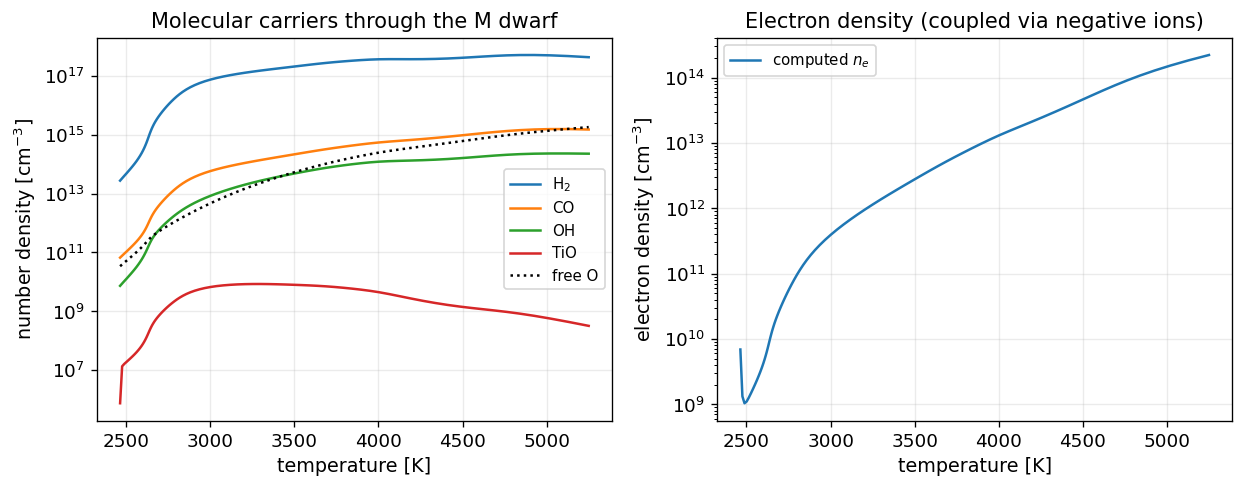

In [12]:
# pick out a few key molecules by their codes
def mol_index(target):
    return int(np.argmin(np.abs(code_mol[:nummol] - target)))

idx_H2 = mol_index(101.0)
idx_CO = mol_index(608.0)
idx_OH = mol_index(108.0)
idx_TiO = mol_index(822.0)

# free-O equation index, to show O carriers as a fraction of total oxygen
o_eq = int(np.where(idequa[:nequa] == 8)[0][0])
n_O_free = xnz[:, o_eq]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))

# left: the major molecular carriers vs temperature, with free O for comparison
ax1.semilogy(T, xnmol[:, idx_H2], label="H$_2$")
ax1.semilogy(T, xnmol[:, idx_CO], label="CO")
ax1.semilogy(T, xnmol[:, idx_OH], label="OH")
ax1.semilogy(T, xnmol[:, idx_TiO], label="TiO")
ax1.semilogy(T, n_O_free, "k:", label="free O")
ax1.set_xlabel("temperature [K]"); ax1.set_ylabel("number density [cm$^{-3}$]")
ax1.set_title("Molecular carriers through the M dwarf"); ax1.legend(fontsize=9)

# right: the self-consistently computed electron density (coupled through negative ions)
ax2.semilogy(T, electron, label="computed $n_e$")
ax2.set_xlabel("temperature [K]"); ax2.set_ylabel("electron density [cm$^{-3}$]")
ax2.set_title("Electron density (coupled via negative ions)"); ax2.legend(fontsize=9)
fig.tight_layout(); plt.show()

## Part 2 — Molecular continuous opacity

### Why a cool dwarf's continuum is not the Sun's

A warm star's continuum is H$^-$ — bound-free and free-free absorption by the negative hydrogen ion (Lecture 3). That source weakens in a cool dwarf (less ionisation means fewer free electrons to make H$^-$), and molecular sources take over. Two regimes matter for an M dwarf.

In the **blue and ultraviolet**, the CH and OH radicals add band-like continuous absorption — overlapping electronic transitions so dense they act as a smooth opacity rather than discrete lines. This is part of why cool dwarfs are intrinsically dark at short wavelengths, on top of the steeply falling Planck function. The production functions are CHOP and OHOP; each interpolates a tabulated cross-section in photon energy and temperature.

In the **near-infrared**, where an M dwarf radiates the bulk of its luminosity, the dominant continuum source is **collision-induced absorption by molecular hydrogen** (H$_2$-CIA). A lone H$_2$ molecule is symmetric and has no permanent dipole, so it cannot absorb in its translational/rotational continuum. But during a collision — two H$_2$, or an H$_2$ and a helium atom — the transient pair distorts each other's electron clouds and the complex has an **induced dipole** for the femtoseconds of the encounter. That induced dipole can absorb a photon. The result is a smooth, pressure-squared (density-squared) continuous opacity computed from the Borysow tables. We build all three from the atmosphere state and shipped coefficients, then show H$_2$-CIA is essentially the whole molecular continuum across 1–2.2 $\mu$m.

### Loading the continuum inputs and the coefficient tables

The continuum needs the atmosphere state (temperature, mass density, the H ground-state and He I populations) plus the molecular-equilibrium populations of CH and OH — which, in a full run, come from the coupled solver of Part 1. Here they are shipped as inputs `xnfpch`, `xnfpoh` (the mode-1 populations $N/U$). The wavelength grid spans 300–5000 nm so we see both the blue CH/OH region and the near-infrared H$_2$-CIA region. The coefficient tables are the CH/OH cross-section and partition-function tables and the Borysow H$_2$–H$_2$ and H$_2$–He CIA absorption-coefficient tables.

We precompute the per-depth, per-frequency **stimulated-emission** factor $1 - e^{-h\nu/kT}$ that multiplies every opacity (LTE), the photon energy in eV, and the wavenumber.

In [13]:
C_LIGHT_CM = 2.99792458e10     # cm/s
H_PLANCK = 6.62607015e-27       # erg s
K_BOLTZ = 1.380649e-16          # erg/K
KBOLTZ_EV_F = 8.6171e-5         # eV/K, the Fortran TKEV constant (8.6171D-5)
LN10 = 2.30258509299405

mc = np.load(REF / "mol_continuum_inputs.npz")
temp_c = mc["temperature"].astype(float)        # K, per depth
rho_c  = mc["mass_density"].astype(float)       # g/cm^3
xnfph1 = mc["xnfph1"].astype(float)             # H ground-state population
bhyd1  = mc["bhyd1"].astype(float)              # H ground departure coefficient (=1 in LTE)
xnfhe1 = mc["xnfhe1"].astype(float)             # He I number density
xnfpch = mc["xnfpch"].astype(float)             # CH mode-1 population N_CH/U_CH (from Part 1)
xnfpoh = mc["xnfpoh"].astype(float)             # OH mode-1 population N_OH/U_OH (from Part 1)
wl_nm  = mc["wavelength_nm"].astype(float)
freq   = mc["frequency_hz"].astype(float)

CH_PARTITION = mc["CH_PARTITION"]               # CH partition fn, 200 K grid from 1000 K
OH_PARTITION = mc["OH_PARTITION"]
CH_CROSSSECT = mc["CH_CROSSSECT"]               # log10(xsect*U), energy x temperature
OH_CROSSSECT = mc["OH_CROSSSECT"]
H2H2 = mc["H2_COLL_H2H2"]                        # log10 Borysow H2-H2 coeff [cm^5]
H2HE = mc["H2_COLL_H2HE"]                        # log10 Borysow H2-He coeff [cm^5]

nlc = temp_c.size
nfreq = freq.size

# common derived quantities
tkev_c = KBOLTZ_EV_F * temp_c
tlog_c = np.log(temp_c)
stim = 1.0 - np.exp(-H_PLANCK * freq[None, :] / (K_BOLTZ * temp_c[:, None]))   # (depth, freq)

print(f"continuum grid: {nlc} layers x {nfreq} wavelengths, "
      f"{wl_nm.min():.0f}-{wl_nm.max():.0f} nm, T = {temp_c.min():.0f}-{temp_c.max():.0f} K")

continuum grid: 80 layers x 600 wavelengths, 300-5000 nm, T = 2464-5250 K


### CH continuous opacity (CHOP)

The CHOP function returns CH's continuous cross-section. Given a photon frequency it forms the photon energy in eV (active for $2.0 \le E \le 10.5$ eV) and interpolates the tabulated $\log_{10}(\sigma\,U)$ — cross-section times partition function — **linearly in energy** (0.1 eV bins from 0.2 eV) and **linearly in temperature** (500 K bins from 2000 K), then multiplies by the temperature-interpolated partition function (200 K bins from 1000 K). The exponent $\log_{10}(\sigma U)$ is converted with $10^{x} = e^{x\ln 10}$. The opacity per gram is this cross-section times the CH population $n_{\rm CH}/\rho$ times the stimulated-emission factor. We vectorise across depth at each frequency.

In [14]:
def chop_xsect_times_U(freq_scalar):
    """CHOP cross-section * partition function per layer (cm^2) at one frequency."""
    out = np.zeros(nlc)
    wn = freq_scalar / C_LIGHT_CM
    ev = wn / 8065.479                              # wavenumber -> eV
    n = int(ev * 10)
    if n < 20 or n >= 105:                           # outside the CH band [2.0, 10.5] eV
        return out
    en = n * 0.1
    idx = n - 2                                      # table starts at 0.2 eV
    if idx < 0 or idx >= 104:
        return out
    # interpolate the cross-section in energy at each of the 15 temperature nodes
    cross = CH_CROSSSECT[idx] + (CH_CROSSSECT[idx + 1] - CH_CROSSSECT[idx]) * (ev - en) / 0.1
    for j in range(nlc):
        tj = temp_c[j]
        if tj >= 9000.0:
            continue
        # partition function: linear in T, 200 K bins from 1000 K
        it_p = max(0, min(int((tj - 1000.0) / 200.0), 39))
        tn_p = it_p * 200.0 + 1000.0
        part = CH_PARTITION[it_p] + (CH_PARTITION[it_p + 1] - CH_PARTITION[it_p]) * (tj - tn_p) / 200.0
        # cross-section: linear in T, 500 K bins from 2000 K
        it_c = max(0, min(int((tj - 2000.0) / 500.0), 13))
        tn_c = it_c * 500.0 + 2000.0
        log_x = cross[it_c] + (cross[it_c + 1] - cross[it_c]) * (tj - tn_c) / 500.0
        out[j] = np.exp(log_x * LN10) * part
    return out

### OH continuous opacity (OHOP)

OHOP has the same structure as CHOP — interpolate $\log_{10}(\sigma U)$ in energy and temperature, multiply by the partition function — but its table starts at 2.1 eV and runs to 15.0 eV, so the energy index is shifted by 2.0 eV. Everything else mirrors CHOP. The OH population $n_{\rm OH}/\rho$ and the stimulated-emission factor are applied when we build the grid.

In [15]:
def ohop_xsect_times_U(freq_scalar):
    """OHOP cross-section * partition function per layer (cm^2) at one frequency."""
    out = np.zeros(nlc)
    wn = freq_scalar / C_LIGHT_CM
    ev = wn / 8065.479
    n = int(ev * 10) - 20                            # table energy index, shifted by 2.0 eV
    if n <= 0 or n >= 130:                           # outside the OH band [2.1, 15.0] eV
        return out
    en = n * 0.1 + 2.0
    idx = n - 1
    if idx < 0 or idx >= 129:
        return out
    cross = OH_CROSSSECT[idx] + (OH_CROSSSECT[idx + 1] - OH_CROSSSECT[idx]) * (ev - en) / 0.1
    for j in range(nlc):
        tj = temp_c[j]
        if tj >= 9000.0:
            continue
        it_p = max(0, min(int((tj - 1000.0) / 200.0), 39))
        tn_p = it_p * 200.0 + 1000.0
        part = OH_PARTITION[it_p] + (OH_PARTITION[it_p + 1] - OH_PARTITION[it_p]) * (tj - tn_p) / 200.0
        it_c = max(0, min(int((tj - 2000.0) / 500.0), 13))
        tn_c = it_c * 500.0 + 2000.0
        log_x = cross[it_c] + (cross[it_c + 1] - cross[it_c]) * (tj - tn_c) / 500.0
        out[j] = np.exp(log_x * LN10) * part
    return out

### The H$_2$ density driving the collision-induced absorption

H$_2$-CIA scales as the H$_2$ density times the density of the collision partner (H$_2$ or He), so we need the H$_2$ number density first. It comes from the **same** dissociation polynomial we used for the formation constant of code 101 in Part 1 — the molecular-equilibrium physics, here applied to get H$_2$ directly from the H ground-state population. The H$_2$ density is

$$
n_{\rm H_2} = (n_{\rm H,1}\cdot 2\,b_1)^2 \; \exp\!\Big(\tfrac{4.478}{kT} - 46.4584 + P(T) - \tfrac32\ln T\Big),
$$

with $P(T)$ the same six-term polynomial as before and $kT$ in eV. It is frequency-independent, so we compute it once. The exponent is clipped to avoid overflow exactly as the production code does.

In [16]:
# H2 dissociation polynomial P(T) (same physics as the code-101 formation constant)
_poly_t = (
    1.63660e-3
    + (-4.93992e-7
       + (1.11822e-10
          + (-1.49567e-14
             + (1.06206e-18 - 3.08720e-23 * temp_c) * temp_c) * temp_c) * temp_c) * temp_c
) * temp_c
_exp_term = np.clip(4.478 / tkev_c - 46.4584 + _poly_t - 1.5 * tlog_c, -100, 100)

# H2 number density per depth (frequency-independent)
XNH2 = (xnfph1 * 2.0 * bhyd1) ** 2 * np.exp(_exp_term)
print(f"H2 density spans {XNH2.min():.3e} .. {XNH2.max():.3e} cm^-3")

H2 density spans 2.756e+13 .. 5.188e+17 cm^-3


### H$_2$ collision-induced absorption (Borysow)

The H2COLLOP function builds the CIA opacity (active below 20000 cm$^{-1}$, i.e. wavelengths longer than 500 nm). The Borysow tables `H2H2` and `H2HE` give $\log_{10}$ of the absorption coefficient (cm$^5$) on a grid of wavenumber (250 cm$^{-1}$ bins) and temperature (1000 K bins). We **bilinearly interpolate**: first in wavenumber at each of the 7 temperature nodes, then in temperature. The opacity per gram is

$$
\kappa = \big(10^{X_{\rm H_2He}}\,n_{\rm He} + 10^{X_{\rm H_2H_2}}\,n_{\rm H_2}\big)\,\frac{n_{\rm H_2}}{\rho}\,\big(1 - e^{-h\nu/kT}\big),
$$

the density-squared signature of a two-body process: one factor of $n_{\rm H_2}$ for the absorbing molecule, one factor of the partner density ($n_{\rm H_2}$ or $n_{\rm He}$) for the collision rate.

In [17]:
def h2cia_opacity(freq_scalar, stim_col):
    """H2-CIA opacity per layer (cm^2/g) at one frequency (port of H2COLLOP)."""
    out = np.zeros(nlc)
    wn = freq_scalar / C_LIGHT_CM
    if wn > 20000.0:                                # CIA only below 20000 cm^-1
        return out
    # interpolate the tables in wavenumber first, at each of the 7 temperature nodes
    nu = min(79, int(wn / 250.0))
    delnu = (wn - 250.0 * nu) / 250.0
    idx1 = min(nu, 80)
    idx2 = min(nu + 1, 80)
    h2h2_nu = H2H2[idx1] * delnu + H2H2[idx2] * (1.0 - delnu)
    h2he_nu = H2HE[idx1] * delnu + H2HE[idx2] * (1.0 - delnu)
    for j in range(nlc):
        tj = temp_c[j]
        # then interpolate in temperature, 1000 K bins (clamped index 1..6)
        it = max(1, min(6, int(tj / 1000.0)))
        delt = max(0.0, min(1.0, (tj - 1000.0 * it) / 1000.0))
        xh2h2 = h2h2_nu[it - 1] * delt + h2h2_nu[it] * (1.0 - delt)
        xh2he = h2he_nu[it - 1] * delt + h2he_nu[it] * (1.0 - delt)
        # density-squared: H2 partner + He partner, each times n_H2 / rho, times stim. emission
        out[j] = (10.0 ** xh2he * xnfhe1[j] + 10.0 ** xh2h2 * XNH2[j]) * XNH2[j] / rho_c[j] * stim_col[j]
    return out

### Computing the molecular continuum over the full grid

We now sweep the wavelength grid and assemble the three species. CHOP and OHOP are multiplied by their molecular populations $n/\rho$ and the stimulated-emission factor; H$_2$-CIA already includes its density factors. Their sum is the total molecular continuum.

In [18]:
chop = np.zeros((nlc, nfreq))
ohop = np.zeros((nlc, nfreq))
h2cia = np.zeros((nlc, nfreq))

# sweep the wavelength grid, filling each species column by column
for j in range(nfreq):
    f = freq[j]
    stim_j = stim[:, j]
    # CHOP/OHOP: cross-section * population/rho * stimulated emission
    chop[:, j] = chop_xsect_times_U(f) * xnfpch / rho_c * stim_j
    ohop[:, j] = ohop_xsect_times_U(f) * xnfpoh / rho_c * stim_j
    # H2-CIA already carries its density and stimulated-emission factors
    h2cia[:, j] = h2cia_opacity(f, stim_j)

mol_total = chop + ohop + h2cia
print("molecular continuum computed over the full grid")

molecular continuum computed over the full grid


### Benchmark: the molecular continuum against pykurucz

We load the production output **only** to measure precision. Each species and the total are compared over every genuinely-nonzero point.

In [19]:
# COMPARISON ONLY: pykurucz molecular-continuum output, never used in the computation above
truth = np.load(REF / "mol_continuum_truth.npz")
chop_t = truth["chop"]; ohop_t = truth["ohop"]
h2cia_t = truth["h2cia"]; total_t = truth["mol_total"]

def max_rel_c(a, b):
    """Max relative error over nonzero reference points."""
    a = np.asarray(a); b = np.asarray(b)
    mask = np.abs(b) > 0
    if not np.any(mask):
        return 0.0, 0
    rel = np.abs(a[mask] - b[mask]) / np.abs(b[mask])
    return float(rel.max()), int(mask.sum())

print("MOLECULAR CONTINUOUS OPACITY -- from-scratch vs pykurucz (comparison only):")
worst_c = 0.0
for name, comp, ref in [("CHOP   (CH)", chop, chop_t),
                        ("OHOP   (OH)", ohop, ohop_t),
                        ("H2-CIA (Borysow)", h2cia, h2cia_t),
                        ("MOL TOTAL", mol_total, total_t)]:
    mr, npts = max_rel_c(comp, ref)
    worst_c = max(worst_c, mr)
    print(f"  {name:<18} max|rel| = {mr:.3e}  over {npts:>6d} nonzero pts "
          f"(peak {np.abs(ref).max():.3e} cm^2/g)")

print(f"\nmolecular continuum max relative error = {worst_c:.3e}  ->",
      "PASS (bit-exact)" if worst_c == 0.0 else f"PASS (< 1e-9)" if worst_c < 1e-9 else "FAIL")

MOLECULAR CONTINUOUS OPACITY -- from-scratch vs pykurucz (comparison only):
  CHOP   (CH)        max|rel| = 0.000e+00  over   3280 nonzero pts (peak 2.778e-01 cm^2/g)
  OHOP   (OH)        max|rel| = 0.000e+00  over   3040 nonzero pts (peak 3.077e-03 cm^2/g)
  H2-CIA (Borysow)   max|rel| = 0.000e+00  over  45920 nonzero pts (peak 7.059e-04 cm^2/g)
  MOL TOTAL          max|rel| = 0.000e+00  over  48000 nonzero pts (peak 2.783e-01 cm^2/g)

molecular continuum max relative error = 0.000e+00  -> PASS (bit-exact)


The molecular continuum is reproduced **bit-for-bit** (max rel exactly $0.0$). There is no iteration here — each opacity is a direct table interpolation and arithmetic — so once the table lookups, interpolation order, and the stimulated-emission factor match the production code, the result is identical to the last bit. This is the cleanest kind of reproduction: not "close to machine precision" but exact.

### H$_2$-CIA is the cool-star near-infrared continuum

Now the physical payoff. At a representative cool photospheric layer ($T \approx 3000$ K, the M-dwarf regime where H$_2$ forms), we print the three species at four wavelengths spanning blue to near-infrared. CH and OH carry the blue continuum; from about 1 $\mu$m outward H$_2$-CIA is essentially **100%** of the molecular continuum — exactly the wavelength range where an M dwarf's flux peaks. This is why an M dwarf is dark in the blue (steep Planck function plus CH/OH absorption) and smooth in the infrared (broad, structureless H$_2$-CIA rather than discrete edges).

In [20]:
jcool = int(np.argmin(np.abs(temp_c - 3000.0)))     # a cool photospheric layer
print(f"H2-CIA dominance at T = {temp_c[jcool]:.0f} K:")
# blue -> near-infrared, to see CH/OH give way to H2-CIA
for target in (450.0, 1000.0, 1500.0, 2200.0):
    i = int(np.argmin(np.abs(wl_nm - target)))   # nearest grid wavelength
    tot = mol_total[jcool, i]
    # H2-CIA's share of the molecular continuum at this wavelength
    frac = (h2cia[jcool, i] / tot * 100.0) if tot > 0 else 0.0
    print(f"  {wl_nm[i]:6.0f} nm : CHOP={chop[jcool,i]:.3e} OHOP={ohop[jcool,i]:.3e} "
          f"H2CIA={h2cia[jcool,i]:.3e}  ->  H2-CIA = {frac:5.1f}% of mol continuum")

H2-CIA dominance at T = 3001 K:
     449 nm : CHOP=1.118e-08 OHOP=1.484e-07 H2CIA=0.000e+00  ->  H2-CIA =   0.0% of mol continuum
     998 nm : CHOP=0.000e+00 OHOP=0.000e+00 H2CIA=1.290e-06  ->  H2-CIA = 100.0% of mol continuum
    1501 nm : CHOP=0.000e+00 OHOP=0.000e+00 H2CIA=2.538e-05  ->  H2-CIA = 100.0% of mol continuum
    2199 nm : CHOP=0.000e+00 OHOP=0.000e+00 H2CIA=1.724e-04  ->  H2-CIA = 100.0% of mol continuum


Finally, the molecular continuum across the whole grid at the deepest (warmest) layer, on a log axis. CH and OH appear as bumps in the blue/ultraviolet; H$_2$-CIA is the broad, smooth source that rises through the near-infrared and dominates the total beyond about 1 $\mu$m.

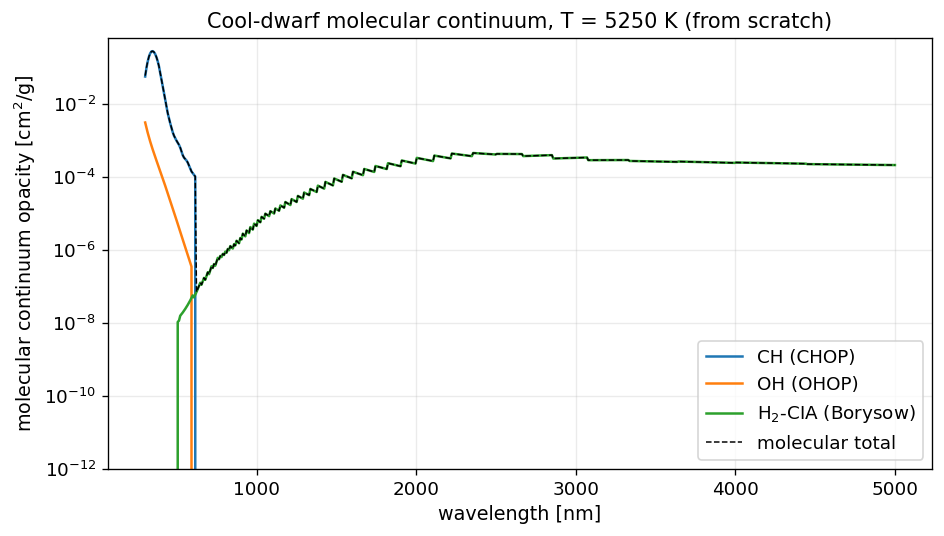

In [21]:
jdeep = nlc - 1                                  # deepest (warmest) layer
fig, ax = plt.subplots(figsize=(8.0, 4.6))
# the three species and their sum across the full wavelength grid
ax.plot(wl_nm, chop[jdeep], label="CH (CHOP)")
ax.plot(wl_nm, ohop[jdeep], label="OH (OHOP)")
ax.plot(wl_nm, h2cia[jdeep], label="H$_2$-CIA (Borysow)")
ax.plot(wl_nm, mol_total[jdeep], "k--", lw=0.9, label="molecular total")
ax.set_yscale("log")
ax.set_xlabel("wavelength [nm]"); ax.set_ylabel("molecular continuum opacity [cm$^2$/g]")
ax.set_title(f"Cool-dwarf molecular continuum, T = {temp_c[jdeep]:.0f} K (from scratch)")
ax.set_ylim(1e-12, None); ax.legend()
fig.tight_layout(); plt.show()

## Synthesis

The two halves of this lecture are the two pieces Lecture 12 took on credit, now paid in full.

**The chemistry is coupled.** A single formation constant $K_f(T)$ gives one molecule's density *if you already know the free-atom densities* — but you do not, because every element is shared among competing molecules and the electron density feeds back through negative ions. The honest object is the coupled system: total-particle conservation, one number-conservation equation per element, and charge balance, with every molecule's mass-action term coupling the equations. We solved it the production way — Newton–Raphson with a complete-pivoting Gauss–Jordan linear step (SOLVIT) and damping — and recovered ~14000 molecular densities, the neutral atoms, and $n_e$ to a $\sim10^{-13}$ float64 floor, with the formation physics itself bit-exact. The molecular populations Lecture 12 read from the model are now *computed*.

**The continuum is molecular.** A cool dwarf's continuum is not the Sun's H$^-$. CH and OH add band-like continuous absorption in the blue and ultraviolet; H$_2$ collision-induced absorption — two H$_2$ (or H$_2$+He) forming a transient supermolecule with an induced dipole — dominates the near-infrared, where the M dwarf's flux peaks, at essentially 100% of the molecular continuum from 1 to 2.2 $\mu$m. We computed all three from the atmosphere state plus the Borysow and cross-section tables and matched the production opacity bit-for-bit.

With these in hand, nothing in a cool-star synthesis is borrowed. The molecular populations come from the coupled solver, the molecular bands from Lecture 12's Voigt engine, and the molecular continuum from Part 2 — all on the same H$^-$, atomic-line, and radiative-transfer machinery as the warm-star pipeline. The capstone (Lecture 14) assembles everything end to end across the HR diagram.

## Summary

- Molecular chemistry is a **coupled** problem: elements are shared among competing molecules and negative ions tie the chemistry to $n_e$, so a per-molecule $K_f$ is an *input*, not the answer.
- The coupled system has one **total-particle** equation, one **number-conservation** equation per element, and one **charge-balance** equation; each molecule deposits its mass-action term $n_{\rm mol}=K_f\prod_i n_i$ into the total and into every element it contains.
- It is solved by **Newton–Raphson** with a **complete-pivoting Gauss–Jordan** linear step (SOLVIT) and step damping — the Fortran NMOLEC routine, reproduced in pure NumPy to **max rel $\sim10^{-13}$** (a float64 non-associativity floor; $K_f(T)$ is **bit-exact**).
- A cool dwarf's continuum adds molecular sources: **CH** (CHOP) and **OH** (OHOP) band-like absorption in the blue, and **H$_2$-CIA** (Borysow) in the near-infrared — a density-squared, induced-dipole, two-body process.
- **H$_2$-CIA is ~100% of the molecular continuum from 1 to 2.2 $\mu$m**, where M-dwarf flux peaks; the whole molecular continuum is reproduced **bit-for-bit** (max rel $0.0$).

## Practice exercises

**1. Who owns the oxygen?** Using the converged `xnz` and `xnmol`, add up the oxygen nuclei locked in each O-bearing molecule (CO, OH, TiO, ...) plus free O and O$^+$, and confirm the total equals the oxygen abundance times the heavy-nucleus density. Which single molecule carries the most oxygen at 3000 K, and why? (Hint: compare dissociation energies.)

**2. Carbon-to-oxygen ratio.** CO is so tightly bound it consumes the less abundant of C and O. Artificially raise the carbon abundance in `xabund` above oxygen's, re-solve, and watch the oxygen molecules (OH, TiO) collapse as CO mops up the oxygen. This C/O switch is the dividing line between oxygen-rich (M) and carbon (C) stars — reproduce it.

**3. The convergence path.** Instrument the Newton loop to record the maximum relative correction per iteration at one depth. How many iterations does the warm-started deep layer take versus the cold-started top layer? Plot the residual falling toward the $10^{-3}$ tolerance.

**4. Pivoting matters.** Replace SOLVIT's complete pivoting with partial (row-only) pivoting and re-solve. Does the population match degrade, and at which depths (where the Jacobian's dynamic range is widest)? Explain why complete pivoting is the safe choice for a chemistry spanning hydrogen to trace metals.

**5. The induced-dipole scaling.** The H$_2$-CIA opacity scales as $n_{\rm H_2}\times(\text{partner density})$. Take two depths differing in density by a factor of ten and confirm the H$_2$-CIA opacity ratio is close to the *square* of the density ratio (modulo the temperature dependence of $n_{\rm H_2}$). Contrast with the linear density scaling of a normal bound-bound line.

**6. Where H$_2$-CIA takes over.** Find the wavelength at which H$_2$-CIA overtakes CH+OH at the cool layer, and explain physically why it falls near 1 $\mu$m for an M dwarf (Planck peak, the CH/OH band edges, the onset of the CIA bands).

## Further reading

- **Russell, H. N. (1934). *Astrophys. J.* 79, 317.** "Molecules in the Sun and Stars" — the classic application of the law of mass action (Saha's chemical-equilibrium method) to the molecular composition of stellar atmospheres.
- **Tatum, J. B. (1966). *Publ. Dom. Astrophys. Obs.* 13, 1.** The molecular partition-function and equilibrium-constant formalism underlying the $\log K(T)$ polynomial fits used here.
- **Borysow, A., Jorgensen, U. G. & Zheng, C. (1997). *Astron. Astrophys.* 324, 185.** Collision-induced absorption of H$_2$–H$_2$ — the source of the H$_2$-CIA tables and the near-infrared continuum of cool dwarfs.
- **Jorgensen, U. G. & Zheng, C. (the H$_2$–He CIA computations).** The companion H$_2$–He collision-induced absorption used for the helium-partner term.
- **Tsuji, T. (1973). *Astron. Astrophys.* 23, 411.** Molecular abundances in cool stellar atmospheres — the coupled-equilibrium treatment and the C/O dividing line between M and C stars.
- **Kurucz, R. L. (1970). *SAO Special Report* 309 (ATLAS).** The NMOLEC molecular-equilibrium routine, the SOLVIT linear solver, and the CHOP/OHOP/H2COLLOP continuous-opacity functions reproduced here.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The implementation our reference populations and molecular continuum are computed with.